In [2]:
import trajectory_generator

import numpy as np
import matplotlib.pyplot as plt


Генерация 100 траекторий с заданными параметрами...
Сгенерировано 10/100 траекторий.
Сгенерировано 20/100 траекторий.
Сгенерировано 30/100 траекторий.
Сгенерировано 40/100 траекторий.
Сгенерировано 50/100 траекторий.
Сгенерировано 60/100 траекторий.
Сгенерировано 70/100 траекторий.
Сгенерировано 80/100 траекторий.
Сгенерировано 90/100 траекторий.
Сгенерировано 100/100 траекторий.

Генерация завершена.
Всего сгенерировано траекторий: 100
Пример длины первой траектории (кол-во точек): 1500
Пример формы первой траектории: (1500, 2)

Визуализация первых 5 сгенерированных траекторий...


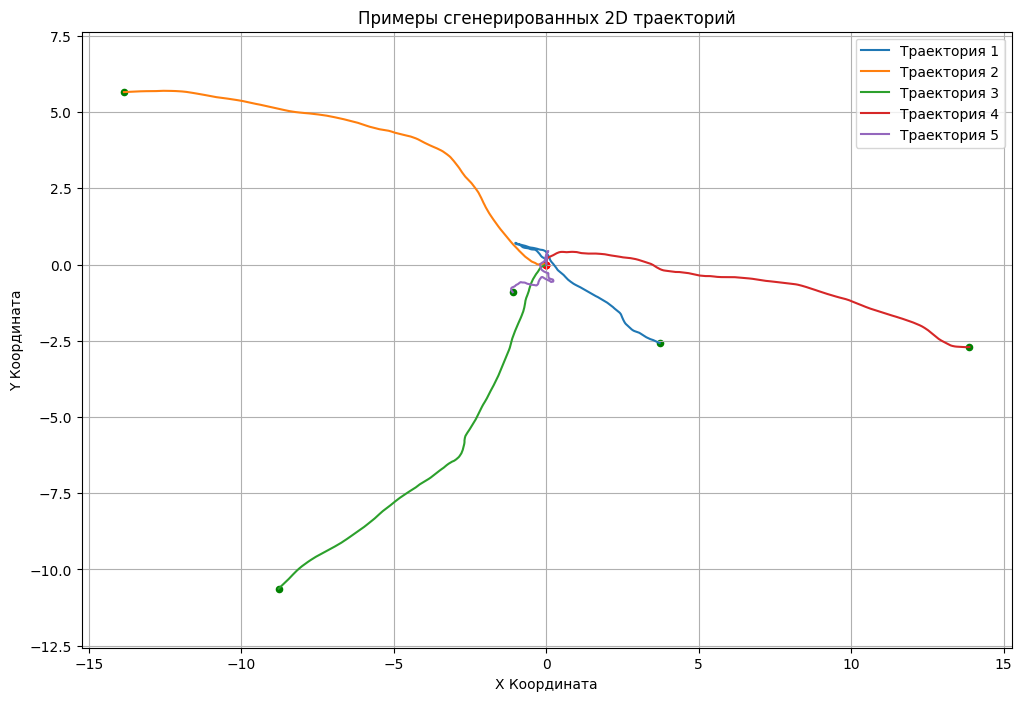

In [3]:
num_trajectories = 100
generated_trajectories = [] # Список для хранения только массивов положений (N, 2)

print(f"Генерация {num_trajectories} траекторий с заданными параметрами...")

# Параметры, которые вы указали для всех 100 траекторий
fixed_params = {
    "total_time": 15.0,
    "delta_t": 0.01,
    "max_acceleration": 2.0,
    "accel_key_points_per_sec": 30,
    "initial_position": (0.0, 0.0),
    "initial_velocity": (0.0, 0.0)
}

for i in range(num_trajectories):
    # Генерируем траекторию, используя ФИКСИРОВАННЫЕ параметры
    # Обратите внимание, что поскольку параметры фиксированы, все 100 траекторий будут идентичными,
    # за исключением внутренней случайности в CubicSpline, но она все равно будет очень похожей.
    # Если вы хотите РАЗНЫЕ траектории с этими ОБЩИМИ характеристиками,
    # нужно будет добавить рандомизацию к initial_position, initial_velocity, и seed внутри цикла.
    
    # Чтобы получить 100 РАЗНЫХ траекторий с *похожими* характеристиками,
    # раскомментируйте следующие строки и закомментируйте fixed_params
    # и используйте np.random.seed(i) внутри цикла, или просто полагайтесь
    # на внутреннюю случайность generate_smooth_2d_trajectory.

    # Например, для разных траекторий в рамках заданных параметров:
    # current_initial_pos = (np.random.uniform(-5, 5), np.random.uniform(-5, 5))
    # current_initial_vel = (np.random.uniform(-0.5, 0.5), np.random.uniform(-0.5, 0.5))
    # current_max_accel = np.random.uniform(1.5, 2.5) # Немного варьируем
    # current_accel_key_points = np.random.randint(25, 35) # Немного варьируем

    _, positions, _, _ = trajectory_generator.generate_smooth_2d_trajectory(
        total_time=fixed_params["total_time"],
        delta_t=fixed_params["delta_t"],
        max_acceleration=fixed_params["max_acceleration"],
        accel_key_points_per_sec=fixed_params["accel_key_points_per_sec"],
        initial_position=fixed_params["initial_position"],
        initial_velocity=fixed_params["initial_velocity"]
    )
    generated_trajectories.append(positions)
    
    if (i + 1) % 10 == 0:
        print(f"Сгенерировано {i+1}/{num_trajectories} траекторий.")

print("\nГенерация завершена.")
print(f"Всего сгенерировано траекторий: {len(generated_trajectories)}")

# Проверка длины одной из сгенерированных траекторий
if generated_trajectories:
    print(f"Пример длины первой траектории (кол-во точек): {generated_trajectories[0].shape[0]}")
    print(f"Пример формы первой траектории: {generated_trajectories[0].shape}")

    # Визуализация нескольких сгенерированных траекторий
    print("\nВизуализация первых 5 сгенерированных траекторий...")
    plt.figure(figsize=(12, 8))
    for i in range(min(5, len(generated_trajectories))): # Отрисуем первые 5
        # Используем plot_2d_trajectory для одной траектории, или просто plt.plot для нескольких
        plt.plot(generated_trajectories[i][:, 0], generated_trajectories[i][:, 1], label=f'Траектория {i+1}')
        plt.scatter(generated_trajectories[i][0, 0], generated_trajectories[i][0, 1], color='red', s=20) # Начало
        plt.scatter(generated_trajectories[i][-1, 0], generated_trajectories[i][-1, 1], color='green', s=20) # Конец
    plt.title('Примеры сгенерированных 2D траекторий')
    plt.xlabel('X Координата')
    plt.ylabel('Y Координата')
    plt.grid(True)
    plt.axis('equal') # Сохраняет пропорции
    plt.legend()
    plt.show()

# Если вы хотите увидеть одну из траекторий отдельно с помощью вашей функции plot_2d_trajectory
# (например, первую сгенерированную):
# if generated_trajectories:
#     # Пересоздадим её, чтобы получить time_points для plot_2d_trajectory
#     time_points_single, positions_single, _, _ = generate_smooth_2d_trajectory(
#         total_time=fixed_params["total_time"],
#         delta_t=fixed_params["delta_t"],
#         max_acceleration=fixed_params["max_acceleration"],
#         accel_key_points_per_sec=fixed_params["accel_key_points_per_sec"],
#         initial_position=fixed_params["initial_position"],
#         initial_velocity=fixed_params["initial_velocity"]
#     )
#     plot_2d_trajectory(time_points_single, positions_single, title="Одна сгенерированная траектория с заданными параметрами")


In [ ]:
import torch
import numpy as np
np.random.seed(42)
torch.manual_seed(42)

# --- Параметры для формирования сэмплов ---
input_seq_len = 7
output_seq_len = 3

all_X_train_samples = []
all_y_train_samples = []
all_transformers = [] # Список для хранения PointTransformer'ов для каждого сэмпла

print("Начало формирования обучающих выборок из сгенерированных траекторий...")

for i, positions in enumerate(generated_trajectories):
    # Пропускаем слишком короткие траектории, которые не могут сформировать сэмплы
    min_required_len = input_seq_len + output_seq_len
    if positions.shape[0] < min_required_len:
        print(f"Траектория {i+1} слишком коротка ({positions.shape[0]} точек) для создания сэмплов. Требуется минимум {min_required_len}. Пропускаем.")
        continue

    try:
        X_current_trajectory, y_current_trajectory, transformers_for_this_traj = \
            trajectory_generator.create_training_data_from_long_trajectory_with_normalization(
                positions,
                input_seq_len=input_seq_len,
                output_seq_len=output_seq_len
            )
        
        all_X_train_samples.append(X_current_trajectory)
        all_y_train_samples.append(y_current_trajectory)
        all_transformers.extend(transformers_for_this_traj) # Собираем все трансформеры

        # if (i + 1) % 10 == 0: # Закомментировано, чтобы уменьшить вывод, если траекторий много
        #     print(f"Обработано {i+1} траекторий.")

    except ValueError as e:
        print(f"Ошибка при обработке траектории {i+1}: {e}. Пропускаем.")
        continue


# Объединяем все сэмплы в итоговые тензоры PyTorch
if all_X_train_samples and all_y_train_samples:
    final_X_train = torch.cat(all_X_train_samples, dim=0)
    final_y_train = torch.cat(all_y_train_samples, dim=0)
else:
    print("Внимание: Не удалось сформировать ни одного обучающего сэмпла из всех траекторий. Проверьте их длительность.")
    final_X_train = torch.empty(0, input_seq_len, 2, dtype=torch.float32)
    final_y_train = torch.empty(0, output_seq_len, 2, dtype=torch.float32)

print("\n--- Формирование датасета завершено ---")
print(f"Общее количество обучающих сэмплов: {final_X_train.shape[0]}")
print(f"Итоговая форма X_train: {final_X_train.shape}")
print(f"Итоговая форма y_train: {final_y_train.shape}")
print(f"Количество сохраненных трансформеров (для денормализации): {len(all_transformers)}")

# Пример проверки первой нормализованной пары (если сэмплы есть)
if final_X_train.shape[0] > 0:
    print("\nПервый нормализованный X_train сэмпл (должен начинаться с (0,0) и иметь вторую точку на +X):")
    print(final_X_train[0].numpy())
    print("\nСоответствующий первый нормализованный y_train сэмпл:")
    print(final_y_train[0].numpy())

    # Эти assert'ы можно использовать как быстрые проверки
    assert np.allclose(final_X_train[0, 0].numpy(), [0, 0]), "Ошибка нормализации: первая точка X не в (0,0)."
    assert np.isclose(final_X_train[0, 1, 1].numpy(), 0) and final_X_train[0, 1, 0].numpy() > 0, \
           "Ошибка нормализации: вторая точка X не на положительной оси Ox."
    print("\nПроверка нормализации первого сэмпла успешна.")

# Теперь final_X_train и final_y_train готовы для создания PyTorch TensorDataset
# training_dataset = TensorDataset(final_X_train, final_y_train)
# ... и использования с DataLoader для обучения

Начало формирования обучающих выборок из сгенерированных траекторий...
Ошибка при обработке траектории 1: not enough values to unpack (expected 3, got 2). Пропускаем.
Ошибка при обработке траектории 2: not enough values to unpack (expected 3, got 2). Пропускаем.
Ошибка при обработке траектории 3: not enough values to unpack (expected 3, got 2). Пропускаем.
Ошибка при обработке траектории 4: not enough values to unpack (expected 3, got 2). Пропускаем.
Ошибка при обработке траектории 5: not enough values to unpack (expected 3, got 2). Пропускаем.
Ошибка при обработке траектории 6: not enough values to unpack (expected 3, got 2). Пропускаем.
Ошибка при обработке траектории 7: not enough values to unpack (expected 3, got 2). Пропускаем.
Ошибка при обработке траектории 8: not enough values to unpack (expected 3, got 2). Пропускаем.
Ошибка при обработке траектории 9: not enough values to unpack (expected 3, got 2). Пропускаем.
Ошибка при обработке траектории 10: not enough values to unpack (

In [10]:
all_X_train_samples

[]

Генерация 100 траекторий и формирование обучающих выборок...
Предупреждение: Интервал ключевых точек ускорения (0.0385 с) меньше шага дискретизации траектории (0.0500 с). Рекомендуется, чтобы delta_t был меньше accel_control_interval.
Предупреждение: Интервал ключевых точек ускорения (0.0286 с) меньше шага дискретизации траектории (0.0500 с). Рекомендуется, чтобы delta_t был меньше accel_control_interval.
Предупреждение: Интервал ключевых точек ускорения (0.0417 с) меньше шага дискретизации траектории (0.0500 с). Рекомендуется, чтобы delta_t был меньше accel_control_interval.
Предупреждение: Интервал ключевых точек ускорения (0.0303 с) меньше шага дискретизации траектории (0.0500 с). Рекомендуется, чтобы delta_t был меньше accel_control_interval.
Предупреждение: Интервал ключевых точек ускорения (0.0370 с) меньше шага дискретизации траектории (0.0500 с). Рекомендуется, чтобы delta_t был меньше accel_control_interval.
Предупреждение: Интервал ключевых точек ускорения (0.0270 с) меньше ш

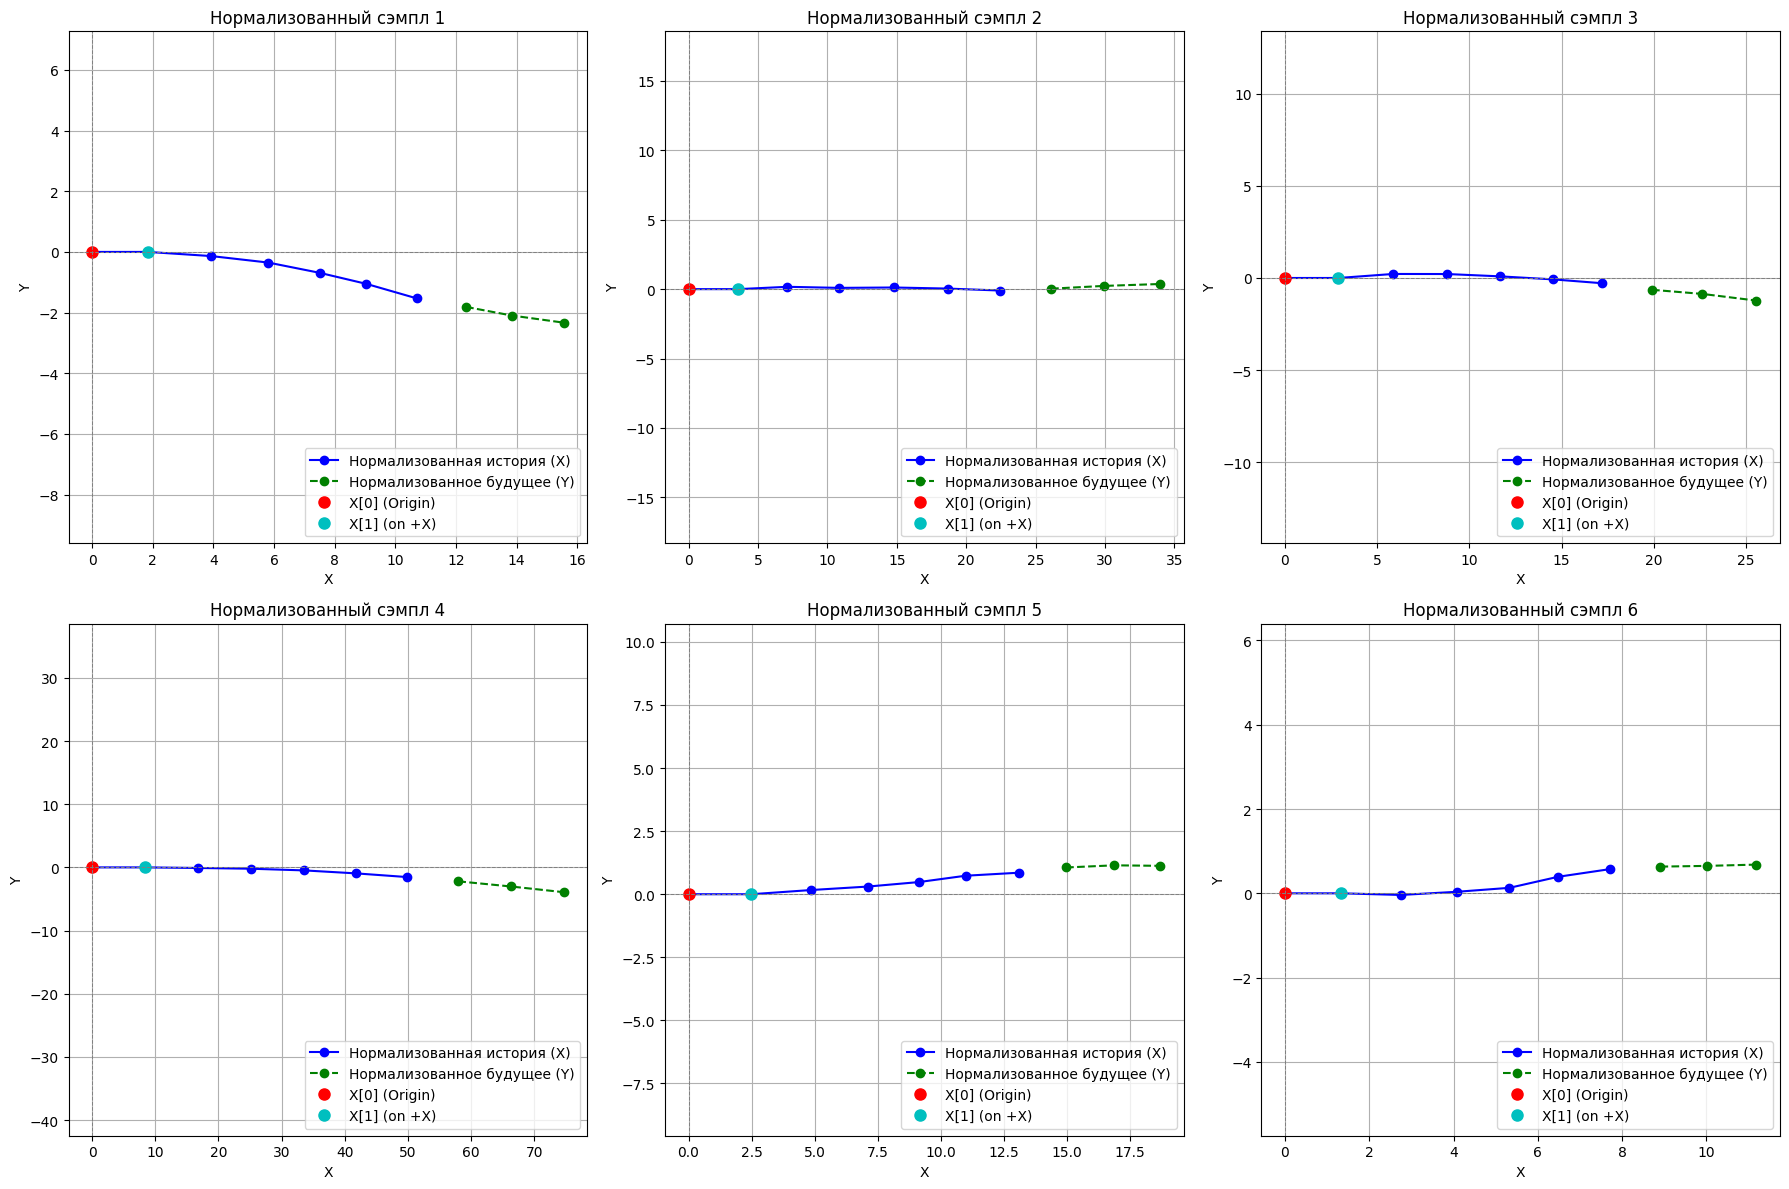

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline # For generate_smooth_2d_trajectory


# --- Main script to generate, process, and combine data ---
if __name__ == "__main__":
    num_trajectories = 100
    trajectory_total_time = 50.0 # Length of each individual trajectory
    trajectory_delta_t = 0.05    # Discretization step for each trajectory
    
    input_seq_len = 7
    output_seq_len = 3

    all_X_train_samples = []
    all_y_train_samples = []

    print(f"Генерация {num_trajectories} траекторий и формирование обучающих выборок...")

    for i in range(num_trajectories):
        # Generate a smooth 2D trajectory
        # We only need the positions (the second return value)
        _, positions, _, _ = trajectory_generator.generate_smooth_2d_trajectory(
            total_time=trajectory_total_time,
            delta_t=trajectory_delta_t,
            max_acceleration=np.random.uniform(50, 150), # Vary max accel for more diverse trajectories
            accel_key_points_per_sec=np.random.randint(10, 40), # Vary key points frequency
            initial_position=(np.random.uniform(-50, 50), np.random.uniform(-50, 50)),
            initial_velocity=(np.random.uniform(-5, 5), np.random.uniform(-5, 5))
        )
        
        # Check if the generated trajectory is long enough to create any samples
        if positions.shape[0] < (input_seq_len + output_seq_len):
            print(f"Траектория {i+1} слишком коротка ({positions.shape[0]} точек) для создания сэмплов. Пропускаем.")
            continue # Skip to the next trajectory if it's too short

        # Create training samples (X, y) from the long trajectory with normalization
        try:
            X_current_trajectory, y_current_trajectory = \
                trajectory_generator.create_training_data_from_long_trajectory_with_normalization(
                    positions,
                    input_seq_len=input_seq_len,
                    output_seq_len=output_seq_len
                )
            
            all_X_train_samples.append(X_current_trajectory)
            all_y_train_samples.append(y_current_trajectory)
            
            if (i + 1) % 10 == 0:
                print(f"Обработано {i+1}/{num_trajectories} траекторий.")

        except ValueError as e:
            print(f"Ошибка при обработке траектории {i+1}: {e}. Пропускаем.")
            continue


    # Combine all generated samples into one large dataset
    if all_X_train_samples and all_y_train_samples:
        final_X_train = torch.cat(all_X_train_samples, dim=0)
        final_y_train = torch.cat(all_y_train_samples, dim=0)
    else:
        print("Не удалось создать ни одного обучающего сэмпла. Проверьте параметры генерации траекторий и их длительность.")
        final_X_train = torch.empty(0, input_seq_len, 2, dtype=torch.float32)
        final_y_train = torch.empty(0, output_seq_len, 2, dtype=torch.float32)

    print("\n--- Результаты формирования датасета ---")
    print(f"Общее количество обучающих сэмплов: {final_X_train.shape[0]}")
    print(f"Итоговая форма X_train: {final_X_train.shape}")
    print(f"Итоговая форма y_train: {final_y_train.shape}")

    # --- Optional: Visualize a few samples from the combined dataset ---
    if final_X_train.shape[0] > 0:
        print("\n--- Визуализация нескольких нормализованных сэмплов ---")
        fig, axes = plt.subplots(2, 3, figsize=(18, 12)) # 6 plots
        axes = axes.flatten()

        for j in range(min(6, final_X_train.shape[0])): # Plot up to 6 samples
            sample_idx = np.random.randint(0, final_X_train.shape[0])
            x_sample = final_X_train[sample_idx].numpy()
            y_sample = final_y_train[sample_idx].numpy()

            ax = axes[j]
            ax.plot(x_sample[:, 0], x_sample[:, 1], 'bo-', label='Нормализованная история (X)')
            ax.plot(y_sample[:, 0], y_sample[:, 1], 'go--', label='Нормализованное будущее (Y)')
            
            # Highlight first two points of X (should be 0,0 and on positive X-axis)
            ax.plot(x_sample[0:1, 0], x_sample[0:1, 1], 'ro', markersize=8, label='X[0] (Origin)')
            ax.plot(x_sample[1:2, 0], x_sample[1:2, 1], 'co', markersize=8, label='X[1] (on +X)')

            ax.set_title(f'Нормализованный сэмпл {j+1}')
            ax.set_xlabel('X')
            ax.set_ylabel('Y')
            ax.grid(True)
            ax.axis('equal')
            ax.legend(loc='lower right')
            ax.axvline(0, color='gray', linestyle='--', linewidth=0.7)
            ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)

        plt.tight_layout()
        plt.show()
    else:
        print("Недостаточно сэмплов для визуализации.")

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt


# --- 2. Network Architecture ---
class TrajectoryPredictor(nn.Module):
    """
    A simple fully connected neural network to predict future 2D points
    from a history of 2D points.
    """
    def __init__(self, input_features, output_features, hidden_size=128):
        """
        Args:
            input_features (int): Number of input features (input_seq_len * 2).
            output_features (int): Number of output features (output_seq_len * 2).
            hidden_size (int): Number of neurons in the hidden layers.
        """
        super(TrajectoryPredictor, self).__init__()
        
        self.fc1 = nn.Linear(input_features, hidden_size)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size, hidden_size // 2) # Example: reduce size
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(hidden_size // 2, output_features)

    def forward(self, x):
        """
        Forward pass through the network.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, input_seq_len, 2).

        Returns:
            torch.Tensor: Output tensor of shape (batch_size, output_seq_len, 2).
        """
        # Flatten the input: from (batch_size, 7, 2) to (batch_size, 14)
        batch_size = x.shape[0]
        x = x.view(batch_size, -1) # -1 infers the dimension: 7 * 2 = 14

        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.relu3(x)
        output = self.fc4(x)

        # Reshape the output: from (batch_size, 6) to (batch_size, 3, 2)
        output_seq_len = self.fc4.out_features // 2 # 6 // 2 = 3
        output = output.view(batch_size, output_seq_len, 2)
        return output

# --- 3. Training Setup and Loop ---
def train_model(model, X_train, y_train):
    # Device configuration
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    hidden_size = 128
    print(f"Using device: {device}")

    # Hyperparameters
    num_samples = 5000  # Number of training trajectories
    input_seq_len = 7
    output_seq_len = 3
    
    input_features = input_seq_len * 2  # 7 points * 2 coordinates = 14
    output_features = output_seq_len * 2 # 3 points * 2 coordinates = 6

    hidden_size = 128
    learning_rate = 0.001
    num_epochs = 100
    batch_size = 64

    # Create DataLoader (for batching)
    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Initialize model, loss function, and optimizer
    criterion = nn.MSELoss() # Mean Squared Error for regression
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    print(f"\nModel Architecture:\n{model}")

    # Training loop
    print("\nStarting training...")
    train_losses = []
    for epoch in range(num_epochs):
        model.train() # Set model to training mode
        running_loss = 0.0
        for i, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            # Backward and optimize
            optimizer.zero_grad() # Clear gradients
            loss.backward()       # Compute gradients
            optimizer.step()      # Update weights

            running_loss += loss.item() * inputs.size(0) # Accumulate batch loss
        
        epoch_loss = running_loss / len(train_dataset)
        train_losses.append(epoch_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")
    
    print("Training finished.")
    return model, train_losses, X_train, y_train, device

# --- 4. Inference and Visualization ---
def predict_and_visualize(model, X_test_sample, y_test_sample, device):
    """
    Makes a prediction and visualizes the input history, true future, and predicted future.
    """
    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculation
        input_tensor = X_test_sample.unsqueeze(0).to(device) # Add batch dimension
        predicted_output = model(input_tensor).cpu().squeeze(0).numpy() # Remove batch dim, to numpy

    input_history = X_test_sample.numpy()
    true_future = y_test_sample.numpy()

    plt.figure(figsize=(10, 7))
    plt.plot(input_history[:, 0], input_history[:, 1], 'bo-', label='Input History (7 points)')
    plt.plot(true_future[:, 0], true_future[:, 1], 'go--', label='True Future (3 points)')
    plt.plot(predicted_output[:, 0], predicted_output[:, 1], 'ro-', label='Predicted Future (3 points)')
    
    # Highlight start/end of history and start/end of prediction
    plt.plot(input_history[0:1, 0], input_history[0:1, 1], 'bs', markersize=8, label='History Start')
    plt.plot(input_history[-1:, 0], input_history[-1:, 1], 'bd', markersize=8, label='History End')
    
    plt.plot(predicted_output[0:1, 0], predicted_output[0:1, 1], 'rs', markersize=8, label='Prediction Start')
    plt.plot(predicted_output[-1:, 0], predicted_output[-1:, 1], 'rd', markersize=8, label='Prediction End')


    plt.title('Trajectory Prediction')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid(True)
    plt.legend()
    plt.axis('equal') # Maintain aspect ratio
    plt.show()


In [9]:
input_seq_len = 7
output_seq_len = 3

input_features = input_seq_len * 2  # 7 points * 2 coordinates = 14
output_features = output_seq_len * 2 # 3 points * 2 coordinates = 6

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
hidden_size = 128

model = TrajectoryPredictor(input_features, output_features, hidden_size).to(device)

trained_model, training_losses, X_data, y_data, device = train_model(model, final_X_train, final_y_train)

Using device: cpu

Model Architecture:
TrajectoryPredictor(
  (fc1): Linear(in_features=14, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (relu3): ReLU()
  (fc4): Linear(in_features=64, out_features=6, bias=True)
)

Starting training...
Epoch [1/100], Loss: 8.0087
Epoch [10/100], Loss: 0.1976
Epoch [20/100], Loss: 0.1863
Epoch [30/100], Loss: 0.1828
Epoch [40/100], Loss: 0.1759
Epoch [50/100], Loss: 0.1717
Epoch [60/100], Loss: 0.1686
Epoch [70/100], Loss: 0.1697
Epoch [80/100], Loss: 0.1693
Epoch [90/100], Loss: 0.1668
Epoch [100/100], Loss: 0.1655
Training finished.


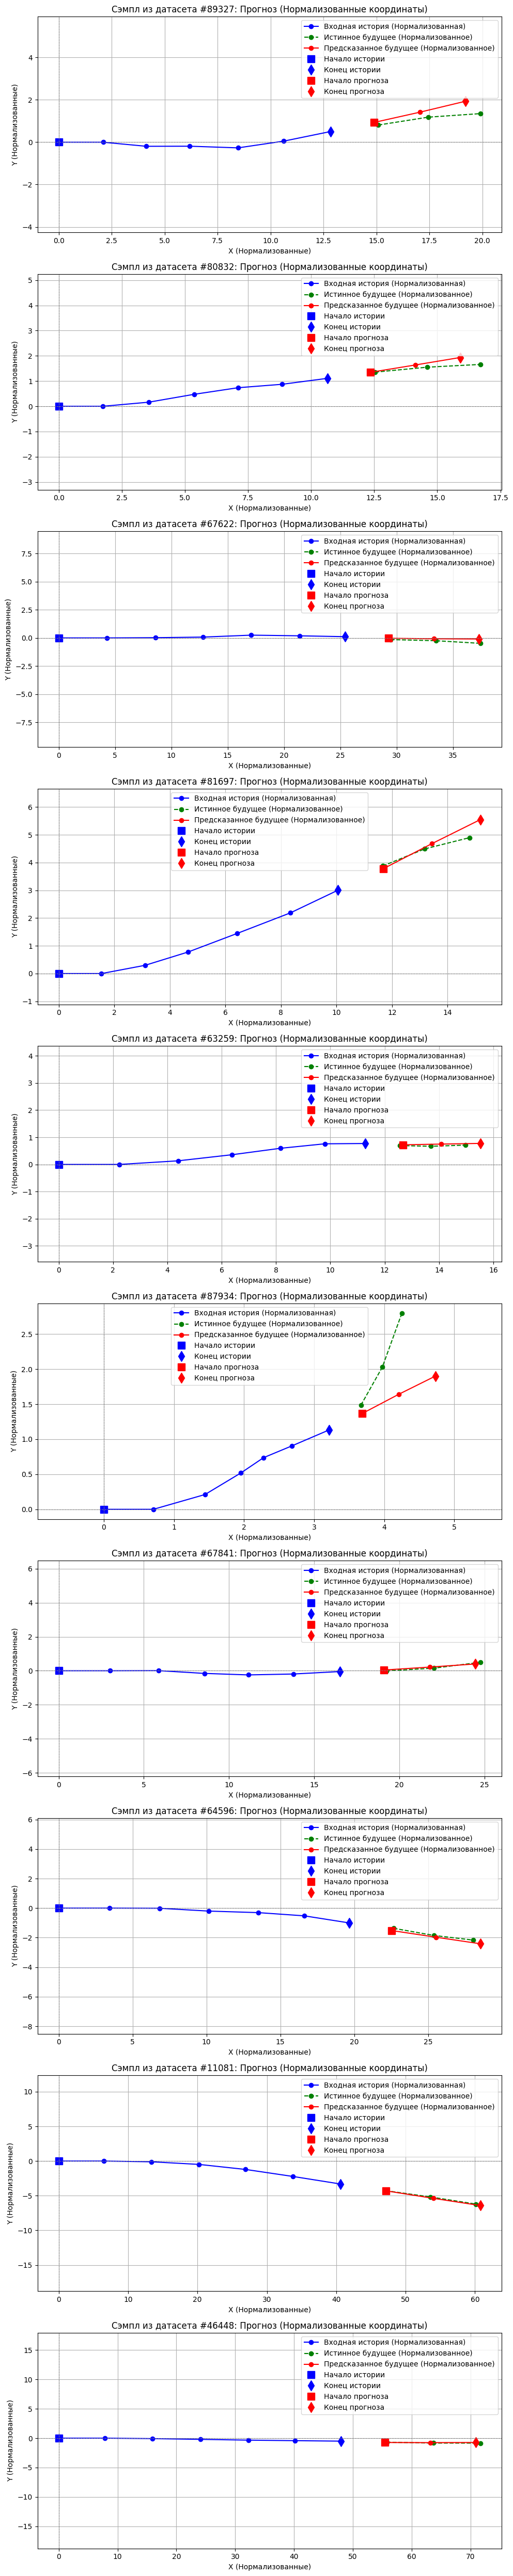

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn # Для определения класса TrajectoryPredictor, если он не импортирован

np.random.seed(42)

# --- Настройка для визуализации ---
num_samples_to_plot = 10 # Количество случайных сэмплов для отрисовки

if final_X_train.shape[0] == 0:
    print("В датасете нет сэмплов для визуализации.")
else:
    # Переводим модель в режим оценки
    model.eval() 

    # Создаем фигуру и набор осей для всех графиков
    fig, axes = plt.subplots(num_samples_to_plot, 1, figsize=(10, 5 * num_samples_to_plot))
    # Если num_samples_to_plot == 1, matplotlib возвращает одну ось, преобразуем в список
    if num_samples_to_plot == 1:
        axes = [axes] 

    # Выбираем случайные индексы сэмплов из вашего объединенного датасета
    sample_indices = np.random.choice(len(final_X_train), num_samples_to_plot, replace=False)

    with torch.no_grad(): # Отключаем расчет градиентов для ускорения
        for i, sample_idx in enumerate(sample_indices):
            # Извлекаем нормализованные X и истинный нормализованный Y для выбранного сэмпла
            x_norm_tensor = final_X_train[sample_idx].unsqueeze(0).to(device) # Добавляем batch_dim и на устройство
            y_norm_true_tensor = final_y_train[sample_idx] # Уже PyTorch Tensor, на CPU

            # Делаем предсказание моделью
            y_norm_pred_tensor = model(x_norm_tensor)

            # Переводим тензоры в NumPy массивы для отрисовки
            x_norm_np = x_norm_tensor.cpu().squeeze(0).numpy()
            y_norm_true_np = y_norm_true_tensor.numpy()
            y_norm_pred_np = y_norm_pred_tensor.cpu().squeeze(0).numpy()

            # --- Отрисовка текущего сэмпла в НОРМАЛИЗОВАННОМ пространстве ---
            ax = axes[i]
            # Входная история (нормализованная): должна начинаться с (0,0), вторая точка на +X
            ax.plot(x_norm_np[:, 0], x_norm_np[:, 1], 'bo-', label='Входная история (Нормализованная)')
            # Истинное будущее (нормализованное):
            ax.plot(y_norm_true_np[:, 0], y_norm_true_np[:, 1], 'go--', label='Истинное будущее (Нормализованное)')
            # Предсказанное будущее (нормализованное):
            ax.plot(y_norm_pred_np[:, 0], y_norm_pred_np[:, 1], 'ro-', label='Предсказанное будущее (Нормализованное)')
            
            # Отмечаем начало и конец последовательностей
            ax.plot(x_norm_np[0:1, 0], x_norm_np[0:1, 1], 'bs', markersize=10, label='Начало истории')
            ax.plot(x_norm_np[-1:, 0], x_norm_np[-1:, 1], 'bd', markersize=10, label='Конец истории')
            ax.plot(y_norm_pred_np[0:1, 0], y_norm_pred_np[0:1, 1], 'rs', markersize=10, label='Начало прогноза')
            ax.plot(y_norm_pred_np[-1:, 0], y_norm_pred_np[-1:, 1], 'rd', markersize=10, label='Конец прогноза')

            # Добавляем оси X и Y, проходящие через (0,0), чтобы подчеркнуть нормализацию
            ax.axvline(0, color='gray', linestyle='--', linewidth=0.7)
            ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)

            ax.set_title(f'Сэмпл из датасета #{sample_idx}: Прогноз (Нормализованные координаты)')
            ax.set_xlabel('X (Нормализованные)')
            ax.set_ylabel('Y (Нормализованные)')
            ax.grid(True)
            ax.legend()
            ax.axis('equal') # Сохраняем пропорции для корректного отображения 2D
    
    plt.tight_layout() # Корректируем расположение графиков
    plt.show()

Генерация 100 траекторий и формирование обучающих выборок...
Предупреждение: Интервал ключевых точек ускорения (0.0435 с) меньше шага дискретизации траектории (0.0500 с). Рекомендуется, чтобы delta_t был меньше accel_control_interval.
Предупреждение: Интервал ключевых точек ускорения (0.0312 с) меньше шага дискретизации траектории (0.0500 с). Рекомендуется, чтобы delta_t был меньше accel_control_interval.
Предупреждение: Интервал ключевых точек ускорения (0.0476 с) меньше шага дискретизации траектории (0.0500 с). Рекомендуется, чтобы delta_t был меньше accel_control_interval.
Предупреждение: Интервал ключевых точек ускорения (0.0256 с) меньше шага дискретизации траектории (0.0500 с). Рекомендуется, чтобы delta_t был меньше accel_control_interval.
Предупреждение: Интервал ключевых точек ускорения (0.0357 с) меньше шага дискретизации траектории (0.0500 с). Рекомендуется, чтобы delta_t был меньше accel_control_interval.
Обработано 10/100 траекторий.
Предупреждение: Интервал ключевых точек

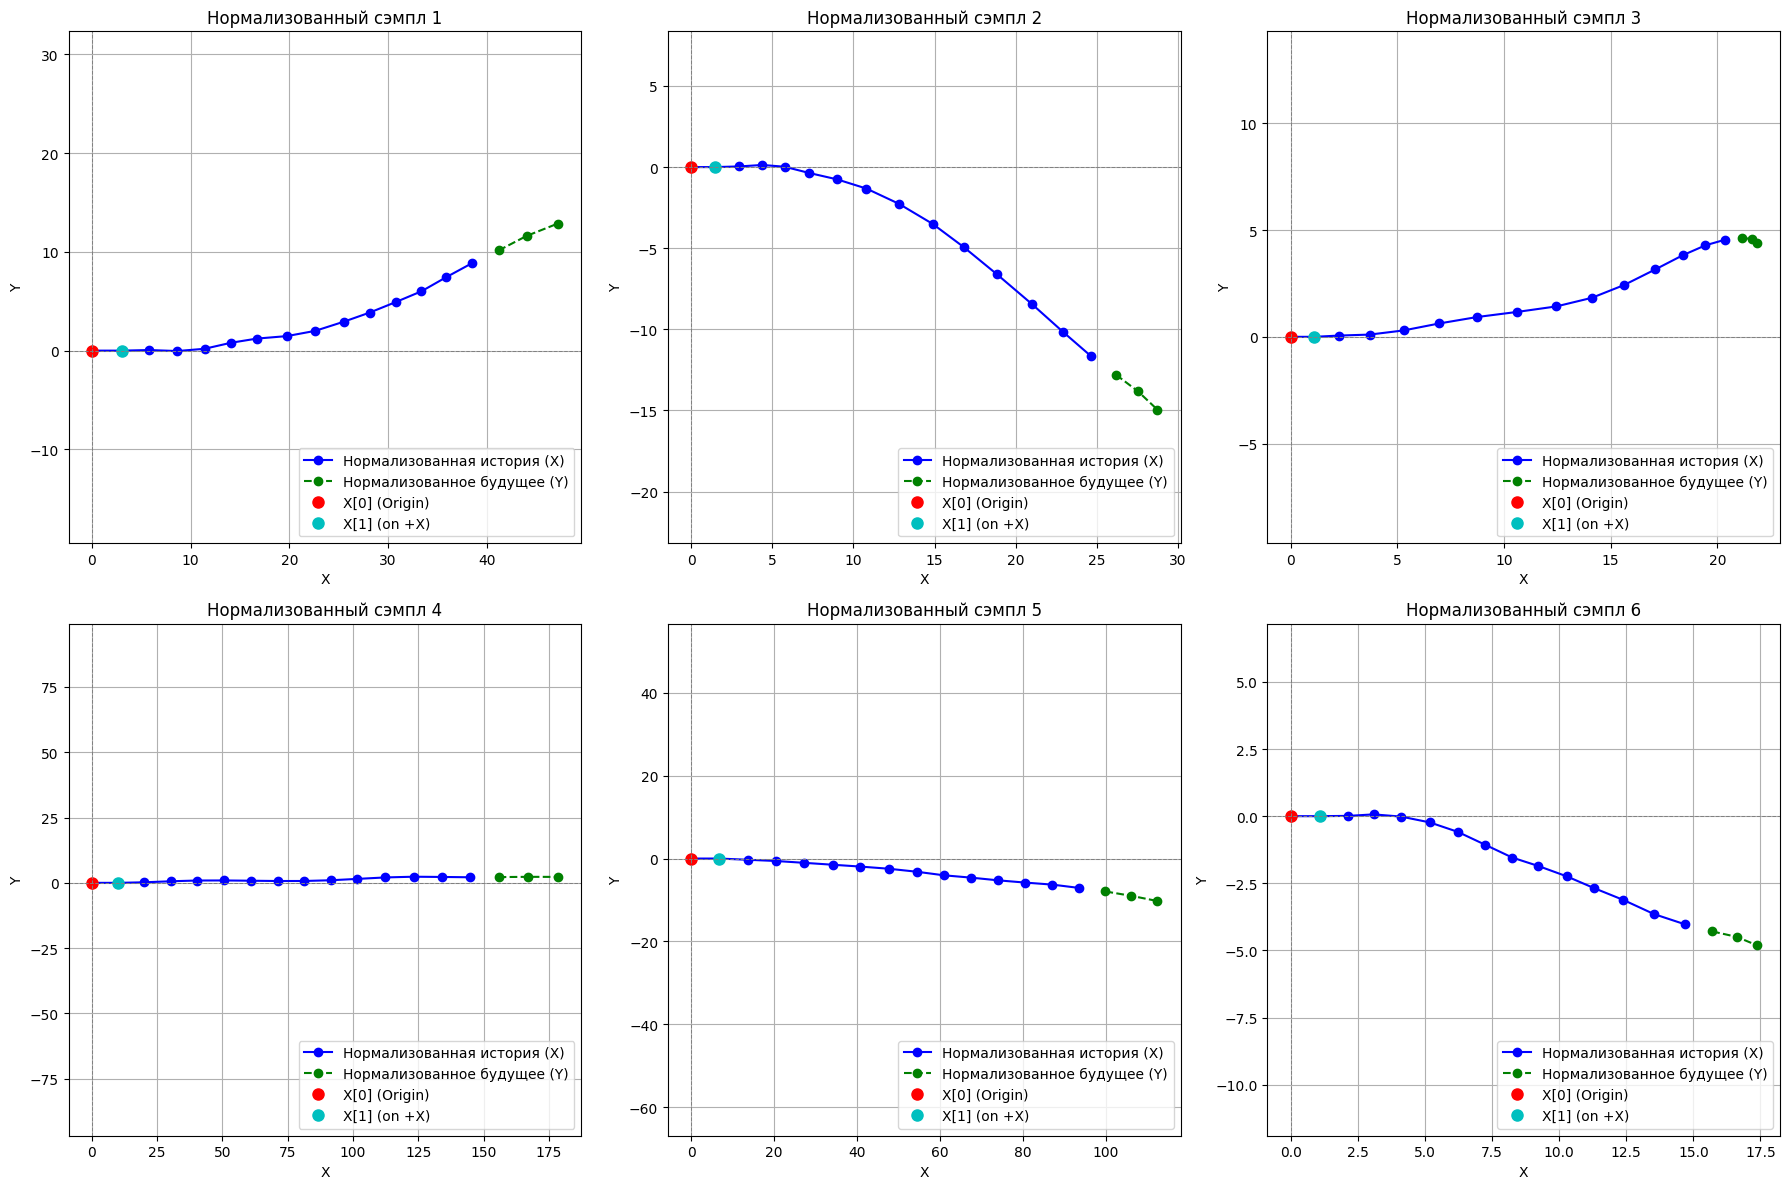

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline # For generate_smooth_2d_trajectory


# --- Main script to generate, process, and combine data ---
if __name__ == "__main__":
    num_trajectories = 100
    trajectory_total_time = 50.0 # Length of each individual trajectory
    trajectory_delta_t = 0.05    # Discretization step for each trajectory
    
    input_seq_len = 15
    output_seq_len = 3

    all_X_train_samples = []
    all_y_train_samples = []

    print(f"Генерация {num_trajectories} траекторий и формирование обучающих выборок...")

    for i in range(num_trajectories):
        # Generate a smooth 2D trajectory
        # We only need the positions (the second return value)
        _, positions, _, _ = trajectory_generator.generate_smooth_2d_trajectory(
            total_time=trajectory_total_time,
            delta_t=trajectory_delta_t,
            max_acceleration=np.random.uniform(50, 150), # Vary max accel for more diverse trajectories
            accel_key_points_per_sec=np.random.randint(10, 40), # Vary key points frequency
            initial_position=(np.random.uniform(-50, 50), np.random.uniform(-50, 50)),
            initial_velocity=(np.random.uniform(-5, 5), np.random.uniform(-5, 5))
        )
        
        # Check if the generated trajectory is long enough to create any samples
        if positions.shape[0] < (input_seq_len + output_seq_len):
            print(f"Траектория {i+1} слишком коротка ({positions.shape[0]} точек) для создания сэмплов. Пропускаем.")
            continue # Skip to the next trajectory if it's too short

        # Create training samples (X, y) from the long trajectory with normalization
        try:
            X_current_trajectory, y_current_trajectory = \
                trajectory_generator.create_training_data_from_long_trajectory_with_normalization(
                    positions,
                    input_seq_len=input_seq_len,
                    output_seq_len=output_seq_len
                )
            
            all_X_train_samples.append(X_current_trajectory)
            all_y_train_samples.append(y_current_trajectory)
            
            if (i + 1) % 10 == 0:
                print(f"Обработано {i+1}/{num_trajectories} траекторий.")

        except ValueError as e:
            print(f"Ошибка при обработке траектории {i+1}: {e}. Пропускаем.")
            continue


    # Combine all generated samples into one large dataset
    if all_X_train_samples and all_y_train_samples:
        final_X_train = torch.cat(all_X_train_samples, dim=0)
        final_y_train = torch.cat(all_y_train_samples, dim=0)
    else:
        print("Не удалось создать ни одного обучающего сэмпла. Проверьте параметры генерации траекторий и их длительность.")
        final_X_train = torch.empty(0, input_seq_len, 2, dtype=torch.float32)
        final_y_train = torch.empty(0, output_seq_len, 2, dtype=torch.float32)

    print("\n--- Результаты формирования датасета ---")
    print(f"Общее количество обучающих сэмплов: {final_X_train.shape[0]}")
    print(f"Итоговая форма X_train: {final_X_train.shape}")
    print(f"Итоговая форма y_train: {final_y_train.shape}")

    # --- Optional: Visualize a few samples from the combined dataset ---
    if final_X_train.shape[0] > 0:
        print("\n--- Визуализация нескольких нормализованных сэмплов ---")
        fig, axes = plt.subplots(2, 3, figsize=(18, 12)) # 6 plots
        axes = axes.flatten()

        for j in range(min(6, final_X_train.shape[0])): # Plot up to 6 samples
            sample_idx = np.random.randint(0, final_X_train.shape[0])
            x_sample = final_X_train[sample_idx].numpy()
            y_sample = final_y_train[sample_idx].numpy()

            ax = axes[j]
            ax.plot(x_sample[:, 0], x_sample[:, 1], 'bo-', label='Нормализованная история (X)')
            ax.plot(y_sample[:, 0], y_sample[:, 1], 'go--', label='Нормализованное будущее (Y)')
            
            # Highlight first two points of X (should be 0,0 and on positive X-axis)
            ax.plot(x_sample[0:1, 0], x_sample[0:1, 1], 'ro', markersize=8, label='X[0] (Origin)')
            ax.plot(x_sample[1:2, 0], x_sample[1:2, 1], 'co', markersize=8, label='X[1] (on +X)')

            ax.set_title(f'Нормализованный сэмпл {j+1}')
            ax.set_xlabel('X')
            ax.set_ylabel('Y')
            ax.grid(True)
            ax.axis('equal')
            ax.legend(loc='lower right')
            ax.axvline(0, color='gray', linestyle='--', linewidth=0.7)
            ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)

        plt.tight_layout()
        plt.show()
    else:
        print("Недостаточно сэмплов для визуализации.")

In [12]:
input_seq_len = 15
output_seq_len = 3

input_features = input_seq_len * 2 
output_features = output_seq_len * 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
hidden_size = 128

model = TrajectoryPredictor(input_features, output_features, hidden_size).to(device)

trained_model, training_losses, X_data, y_data, device = train_model(model, final_X_train, final_y_train)

Using device: cpu

Model Architecture:
TrajectoryPredictor(
  (fc1): Linear(in_features=30, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (relu3): ReLU()
  (fc4): Linear(in_features=64, out_features=6, bias=True)
)

Starting training...
Epoch [1/100], Loss: 29.8098
Epoch [10/100], Loss: 0.3840
Epoch [20/100], Loss: 0.3586
Epoch [30/100], Loss: 0.2691
Epoch [40/100], Loss: 0.2866
Epoch [50/100], Loss: 0.2532
Epoch [60/100], Loss: 0.2559
Epoch [70/100], Loss: 0.2360
Epoch [80/100], Loss: 0.2342
Epoch [90/100], Loss: 0.2328
Epoch [100/100], Loss: 0.2261
Training finished.


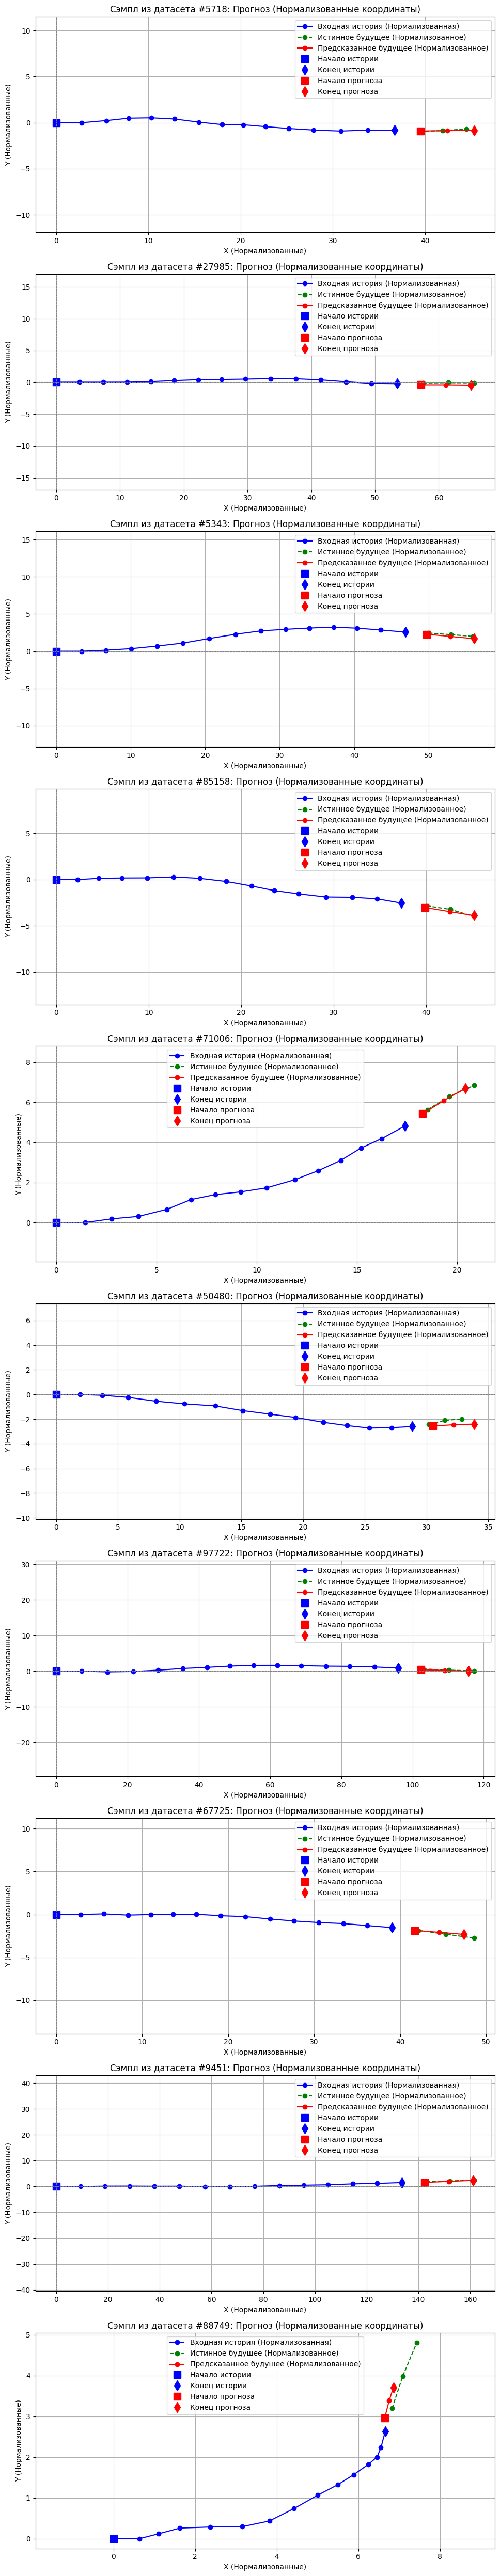

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn # Для определения класса TrajectoryPredictor, если он не импортирован

np.random.seed(42)

# --- Настройка для визуализации ---
num_samples_to_plot = 10 # Количество случайных сэмплов для отрисовки

if final_X_train.shape[0] == 0:
    print("В датасете нет сэмплов для визуализации.")
else:
    # Переводим модель в режим оценки
    model.eval() 

    # Создаем фигуру и набор осей для всех графиков
    fig, axes = plt.subplots(num_samples_to_plot, 1, figsize=(10, 5 * num_samples_to_plot))
    # Если num_samples_to_plot == 1, matplotlib возвращает одну ось, преобразуем в список
    if num_samples_to_plot == 1:
        axes = [axes] 

    # Выбираем случайные индексы сэмплов из вашего объединенного датасета
    sample_indices = np.random.choice(len(final_X_train), num_samples_to_plot, replace=False)

    with torch.no_grad(): # Отключаем расчет градиентов для ускорения
        for i, sample_idx in enumerate(sample_indices):
            # Извлекаем нормализованные X и истинный нормализованный Y для выбранного сэмпла
            x_norm_tensor = final_X_train[sample_idx].unsqueeze(0).to(device) # Добавляем batch_dim и на устройство
            y_norm_true_tensor = final_y_train[sample_idx] # Уже PyTorch Tensor, на CPU

            # Делаем предсказание моделью
            y_norm_pred_tensor = model(x_norm_tensor)

            # Переводим тензоры в NumPy массивы для отрисовки
            x_norm_np = x_norm_tensor.cpu().squeeze(0).numpy()
            y_norm_true_np = y_norm_true_tensor.numpy()
            y_norm_pred_np = y_norm_pred_tensor.cpu().squeeze(0).numpy()

            # --- Отрисовка текущего сэмпла в НОРМАЛИЗОВАННОМ пространстве ---
            ax = axes[i]
            # Входная история (нормализованная): должна начинаться с (0,0), вторая точка на +X
            ax.plot(x_norm_np[:, 0], x_norm_np[:, 1], 'bo-', label='Входная история (Нормализованная)')
            # Истинное будущее (нормализованное):
            ax.plot(y_norm_true_np[:, 0], y_norm_true_np[:, 1], 'go--', label='Истинное будущее (Нормализованное)')
            # Предсказанное будущее (нормализованное):
            ax.plot(y_norm_pred_np[:, 0], y_norm_pred_np[:, 1], 'ro-', label='Предсказанное будущее (Нормализованное)')
            
            # Отмечаем начало и конец последовательностей
            ax.plot(x_norm_np[0:1, 0], x_norm_np[0:1, 1], 'bs', markersize=10, label='Начало истории')
            ax.plot(x_norm_np[-1:, 0], x_norm_np[-1:, 1], 'bd', markersize=10, label='Конец истории')
            ax.plot(y_norm_pred_np[0:1, 0], y_norm_pred_np[0:1, 1], 'rs', markersize=10, label='Начало прогноза')
            ax.plot(y_norm_pred_np[-1:, 0], y_norm_pred_np[-1:, 1], 'rd', markersize=10, label='Конец прогноза')

            # Добавляем оси X и Y, проходящие через (0,0), чтобы подчеркнуть нормализацию
            ax.axvline(0, color='gray', linestyle='--', linewidth=0.7)
            ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)

            ax.set_title(f'Сэмпл из датасета #{sample_idx}: Прогноз (Нормализованные координаты)')
            ax.set_xlabel('X (Нормализованные)')
            ax.set_ylabel('Y (Нормализованные)')
            ax.grid(True)
            ax.legend()
            ax.axis('equal') # Сохраняем пропорции для корректного отображения 2D
    
    plt.tight_layout() # Корректируем расположение графиков
    plt.show()